### Cohen Sutherland Line Clipping

Initial outcodes: c1=1, c2=8
Updating point 1 to (120, 231.11111111111111), new outcode: 0
Updating point 2 to (387.5, 350), new outcode: 0
Both points inside. Accepting line segment.


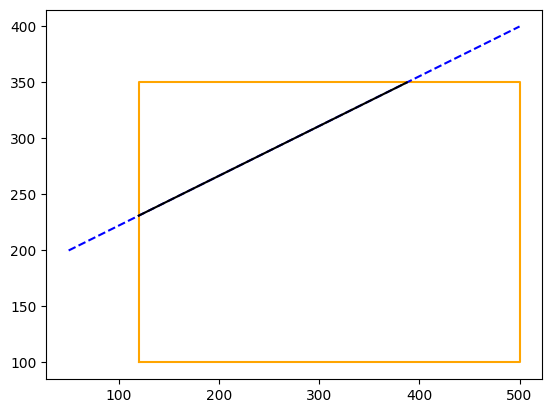

In [1]:
import matplotlib.pyplot as plt

xL, xR, yB, yT = 120, 500, 100, 350

INSIDE, LEFT, RIGHT, BOTTOM, TOP = 0, 1, 2, 4, 8

def outcode(x, y):
    c = INSIDE
    if x < xL: c |= LEFT
    elif x > xR: c |= RIGHT
    if y < yB: c |= BOTTOM
    elif y > yT: c |= TOP
    return c

def cohen_sutherland(x1, y1, x2, y2):
    c1, c2 = outcode(x1, y1), outcode(x2, y2)
    print(f"Initial outcodes: c1={c1}, c2={c2}")

    while True:
        if (c1 | c2) == 0:
            print("Both points inside. Accepting line segment.")
            plt.plot([x1, x2], [y1, y2], color='Black')
            break
        if (c1 & c2) != 0:
            print("Both points outside in the same region. Rejecting line segment.")
            return None
        else:
            x, y = 0, 0
            out = c1 if c1 != 0 else c2
            if out & TOP:
                y = yT
                x = x1 + (x2 - x1) * (yT - y1) / (y2 - y1)
            elif out & BOTTOM:
                y = yB
                x = x1 + (x2 - x1) * (yB - y1) / (y2 - y1)
            elif out & RIGHT:
                x = xR
                y = y1 + (y2 - y1) * (xR - x1) / (x2 - x1)
            elif out & LEFT:
                x = xL
                y = y1 + (y2 - y1) * (xL - x1) / (x2 - x1)
            
            if out == c1:
                x1, y1 = x, y
                c1 = outcode(x1, y1)
                print(f"Updating point 1 to ({x1}, {y1}), new outcode: {c1}")
            else:
                x2, y2 = x, y
                c2 = outcode(x2, y2)
                print(f"Updating point 2 to ({x2}, {y2}), new outcode: {c2}")

if __name__ == "__main__":
    x = [xL, xR, xR, xL, xL]
    y = [yB, yB, yT, yT, yB]
    plt.plot(x, y, color='orange')

    x1, y1, x2, y2 = 50, 200, 500, 400
    plt.plot([x1, x2], [y1, y2], 'b--')
    
    cohen_sutherland(x1, y1, x2, y2)


### Cohen Sutherland Hodgman Polygon Clipping

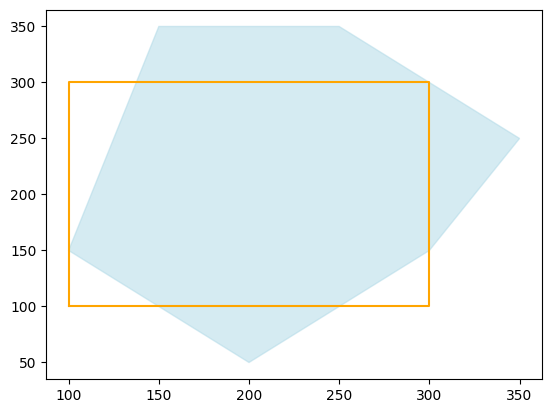

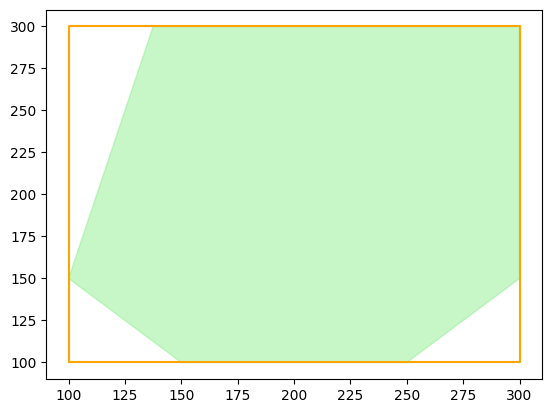

In [2]:
import matplotlib.pyplot as plt

x_min, y_min, x_max, y_max = 100, 100, 300, 300
EDGES = ['LEFT', 'RIGHT', 'BOTTOM', 'TOP']

def inside(p, edge):
    x, y = p
    if edge == 'LEFT': return x >= x_min
    if edge == 'RIGHT': return x <= x_max
    if edge == 'BOTTOM': return y >= y_min
    if edge == 'TOP': return y <= y_max
    return True

def intersection(p1, p2, edge):
    x1, y1 = p1
    x2, y2 = p2
    if edge == 'LEFT':
        x = x_min
        y = y1 + (y2 - y1) * (x_min - x1) / (x2 - x1)
    elif edge == 'RIGHT':
        x = x_max
        y = y1 + (y2 - y1) * (x_max - x1) / (x2 - x1)
    elif edge == 'BOTTOM':
        y = y_min
        x = x1 + (x2 - x1) * (y_min - y1) / (y2 - y1)
    elif edge == 'TOP':
        y = y_max
        x = x1 + (x2 - x1) * (y_max - y1) / (y2 - y1)
    return (x, y)


def clip_polygon(polygon, edge):
    clipped = []
    n = len(polygon)

    for i in range(n):
        curr = polygon[i]
        prev = polygon[i - 1]

        if inside(curr, edge):
            if not inside(prev, edge):
                clipped.append(intersection(prev, curr, edge))
            clipped.append(curr)
        elif inside(prev, edge):
            clipped.append(intersection(prev, curr, edge))
    return clipped

def sutherland_hodgman(polygon):
    for edge in EDGES:
        polygon = clip_polygon(polygon, edge)
    return polygon

if __name__ == "__main__":
    polygon = [(100, 150), (200, 50), (300, 150), (350, 250), (250, 350), (150, 350)]

    plt.fill(*zip(*polygon), color='lightblue', alpha=0.5)

    rect_x = [x_min, x_max, x_max, x_min, x_min]
    rect_y = [y_min, y_min, y_max, y_max, y_min]
    plt.plot(rect_x, rect_y, color='orange')
    plt.show()

    clipped = sutherland_hodgman(polygon)
    if clipped: plt.fill(*zip(*clipped), color='lightgreen', alpha=0.5)
    
    rect_x = [x_min, x_max, x_max, x_min, x_min]
    rect_y = [y_min, y_min, y_max, y_max, y_min]
    plt.plot(rect_x, rect_y, color='orange')
    

### Bezier Curve

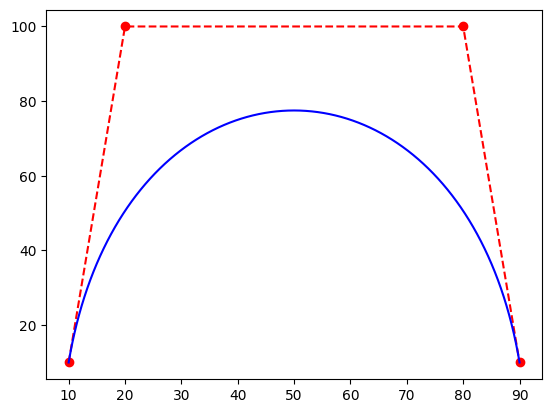

In [3]:
import matplotlib.pyplot as plt
from math import comb

def de_casteljau(controls, u):
    n = len(controls) - 1
    x, y = 0.0, 0.0
    for i in range(n + 1):
        b = comb(n, i) * (u ** i) * ((1 - u) ** (n - i)) # (n choose i) * u^i * (1-u)^(n-i)
        x += controls[i][0] * b
        y += controls[i][1] * b
    return (x, y)

def bezier(controls, steps):
    curve = []
    for i in range(steps + 1):
        u = i / steps
        curve.append(de_casteljau(controls, u))
    return curve

if __name__ == "__main__":
    controls = [(10, 10), (20, 100), (80, 100), (90, 10)]
    curve = bezier(controls, steps=100)

    ctrl_x, ctrl_y = zip(*controls)
    curve_x, curve_y = zip(*curve)
    plt.plot(ctrl_x, ctrl_y, 'ro--', label='Control Points')
    plt.plot(curve_x, curve_y, 'b-', label='Bezier Curve')

### Translate

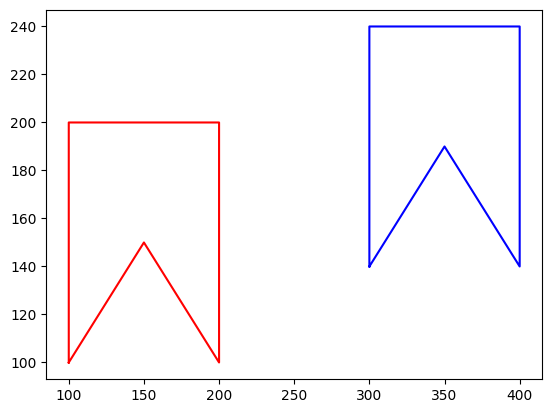

In [4]:
import matplotlib.pyplot as plt

def draw(x, y, color, label):
    # n = len(x)
    xs, ys = x + [x[0]], y + [y[0]]
    plt.plot(xs, ys, color, label=label)

def translate(x, y, tx, ty):
    for i in range(len(x)):
        x[i] += tx
        y[i] += ty
    return x, y

if __name__ == "__main__":
    # Sample data
    x = [100, 100, 200, 200, 150]
    y = [100, 200, 200, 100, 150]

    draw(x, y, color='red', label='Original')

    tx, ty = 200, 40
    x, y = translate(x, y, tx, ty)
    draw(x, y, color='blue', label='Translated')

### Rotation

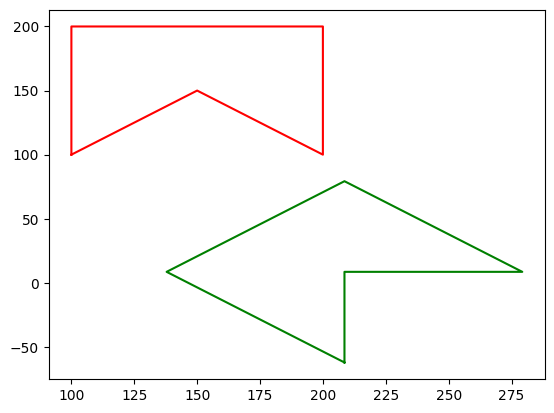

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def draw(x, y, color, label):
    n = len(x)
    xs, ys = x + [x[0]], y + [y[0]]
    plt.plot(xs, ys, color, label=label)

def rotation(x, y, angle, x_pivot, y_pivot):
    th = np.radians(angle)
    ct, st = np.cos(th), np.sin(th)
    xr, yr = [], []
    for xi, yi in zip(x, y):
        dx, dy = xi - x_pivot, yi - y_pivot
        xr.append(x_pivot + dx*ct - dy*st)
        yr.append(y_pivot + dx*st + dy*ct)
    return xr, yr

if __name__ == "__main__":
    # Sample data
    x = [100, 100, 200, 200, 150]
    y = [100, 200, 200, 100, 150]

    draw(x, y, color='red', label='Original')

    angle, x_pivot, y_pivot = 45, 350, 150
    x, y = rotation(x, y, angle, x_pivot, y_pivot)
    draw(x, y, color='green', label='Rotated')

### Scaling

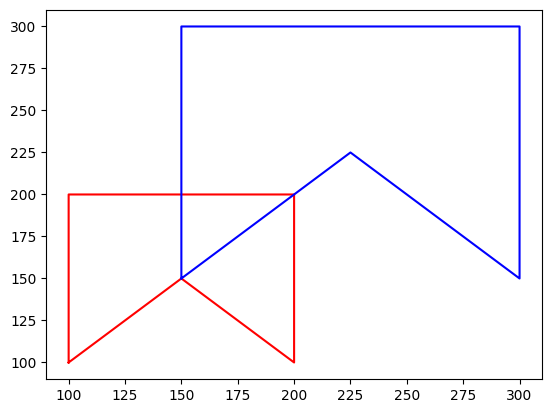

In [6]:
import matplotlib.pyplot as plt

def draw(x, y, color, label):
    n = len(x)
    xs, ys = x + [x[0]], y + [y[0]]
    plt.plot(xs, ys, color, label=label)

def scale(x, y, sfx, sfy):
    for i in range(len(x)):
        x[i] *= sfx
        y[i] *= sfy
    return x, y

if __name__ == "__main__":
    # Sample data
    x = [100, 100, 200, 200, 150]
    y = [100, 200, 200, 100, 150]

    draw(x, y, color='red', label='Original')

    sfx, sfy = 1.5, 1.5
    x, y = scale(x, y, sfx, sfy)
    draw(x, y, color='blue', label='Scale')

### Bresenham Line Drawing Algorithm

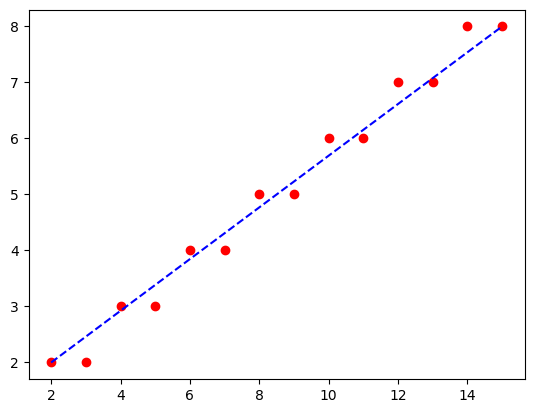

In [7]:
import matplotlib.pyplot as plt

def bresenham_line(x1, y1, x2, y2):
    points = []
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1
    err = dx - dy

    while True:
        points.append((x1, y1))
        if x1 == x2 and y1 == y2:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x1 += sx
        if e2 < dx:
            err += dx
            y1 += sy
    return points


if __name__ == "__main__":
    x1, y1 = 2, 2
    x2, y2 = 15, 8

    points = bresenham_line(x1, y1, x2, y2)
    x, y = zip(*points)
    plt.scatter(x, y, c='red')
    plt.plot([x1, x2], [y1, y2], 'b--')
    plt.show()


### Bresenham Circle Drawing Algorithm

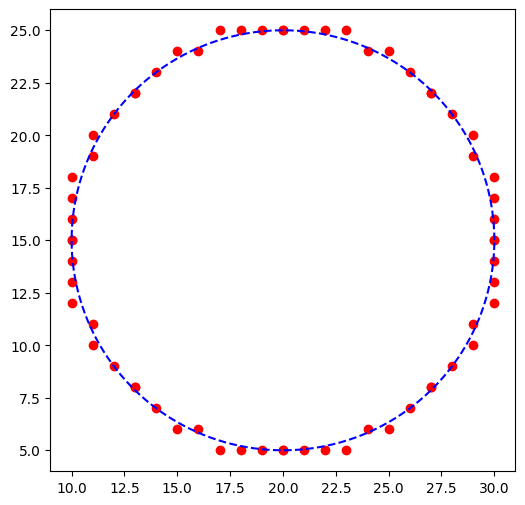

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def bresenham_circle(xc, yc, r):
    x = 0
    y = r
    d = 3 - 2 * r       # midpoint decision parameter
    points = []

    while y >= x:
        # 8-way symmetry
        points.extend([(xc + x, yc + y), (xc - x, yc + y), (xc + x, yc - y), (xc - x, yc - y),(xc + y, yc + x), (xc - y, yc + x),(xc + y, yc - x), (xc - y, yc - x)])
        if d < 0:
            d = d + 4*x + 6
        else:
            d = d + 4*(x - y) + 10
            y -= 1
        x += 1
    return points


if __name__ == "__main__":
    xc, yc, r = 20, 15, 10

    points = bresenham_circle(xc, yc, r)
    x, y = zip(*points)

    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c='red')

    # For comparison: ideal circle
    theta = np.linspace(0, 2 * np.pi, 361)  # ০ থেকে ২π
    x_ideal = xc + r * np.cos(theta)
    y_ideal = yc + r * np.sin(theta)
    plt.plot(x_ideal, y_ideal, 'b--')


### Snowflake Pattern Fractal Geometry

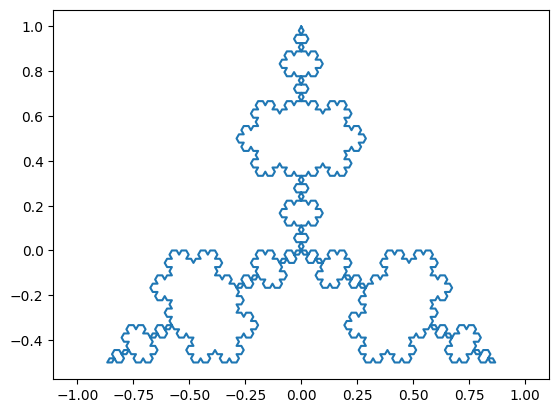

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def koch_curve(p1, p2, order):
    if order == 0:
        return [p1, p2]
    # 1/3, 2/3 ভাগ
    x1, y1 = p1
    x2, y2 = p2
    a = (x1 + (x2 - x1) / 3, y1 + (y2 - y1) / 3)
    b = (x1 + 2 * (x2 - x1) / 3, y1 + 2 * (y2 - y1) / 3)
    # peak বের করা (60° ঘুরিয়ে)
    dx, dy = b[0] - a[0], b[1] - a[1]
    angle = np.pi / 3
    peak = (
        a[0] + dx * np.cos(angle) - dy * np.sin(angle),
        a[1] + dx * np.sin(angle) + dy * np.cos(angle)
    )
    # চারটি অংশে recursion
    return (koch_curve(p1, a, order - 1)[:-1] +
            koch_curve(a, peak, order - 1)[:-1] +
            koch_curve(peak, b, order - 1)[:-1] +
            koch_curve(b, p2, order - 1))

def koch_snowflake(order=4, scale=1.0): 
    # সমবাহু ত্রিভুজের তিনটি শীর্ষ
    p1 = (0, scale)
    p2 = (-scale * np.sin(np.pi / 3), -scale / 2)
    p3 = (scale * np.sin(np.pi / 3), -scale / 2)

    side1 = koch_curve(p1, p2, order)[:-1]
    side2 = koch_curve(p2, p3, order)[:-1]
    side3 = koch_curve(p3, p1, order)
    pts = side1 + side2 + side3
    x, y = zip(*pts)
    return x, y

if __name__ == "__main__":
    x, y = koch_snowflake(order=4)
    plt.plot(x, y)
    plt.axis('equal')
    plt.show()
